# YOLO Multiclass - Pressure Sore Stage Classification (I/II/III/IV)

**Task**: 4-class classification — Stage I, Stage II, Stage III, Stage IV  
**Model**: yolov8x-cls.pt
**Platform**: Kaggle (GPU T4)  

## Notebook Structure

1. Environment setup  
2. Dataset preparation & split  
3. Class distribution analysis  
4. Training  
5. Training curve analysis  
6. Evaluation — confusion matrix (raw + normalised)  
7. Evaluation — full classification report  
8. Evaluation — per-class ROC curves & AUC (One-vs-Rest)  
9. Evaluation — per-class probability distributions   
10. Model export & summary 

## 1. Enviroment Setup

In [1]:
!pip install -q ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 19.4 MB/s eta 0:00:00a 0:00:01


In [2]:
import os, shutil, random
from path import Path
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, classification_report, 
    roc_curve, roc_auc_score
)
from sklearn.preprocessing import label_binarize
from ultralytics import YOLO

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
FIGSIZE = (10,7)

YOLO_BACKBONE = "yolov8x-cls.pt"
RUN_NAME = "multiclass_ps"
print("Environment ready.")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Environment ready.


## 2. Dataset Preparation & Split

Source layout expected:
```
source_dir/
  stage_I/
  stage_II/
  stage_III/
  stage_IV/
```

In [3]:
source_dataset_dir = "/kaggle/input/datasets/cezarytubacki/pressure-sore-stages-dataset/PSD"
yolo_dataset_dir = "/kaggle/working/psdcb_yolo"

def split_dataset_for_yolo(
    source_dir : str,
    dest_dir : str,
    train_ratio : float = 0.70,
    val_ratio : float = 0.20,
    test_ratio : float = 0.10
) -> dict:
    """
    Split an image classification dataset into YOLO train/val/test format.
    Returns a dict with per-class counts for distribution analysis.
    """
    assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-6, "Ratios must sum to 1.0"
    counts = {split: {} for split in ["train", "val", "test"]}

    for split in ["train", "val", "test"]:
        os.makedirs(os.path.join(dest_dir, split), exist_ok=True)

    for class_folder in sorted(os.listdir(source_dir)):
        class_path = os.path.join(source_dir, class_folder)
        if not os.path.isdir(class_path):
            continue
        for split in ["train", "val", "test"]:
            os.makedirs(os.path.join(dest_dir, split, class_folder), exist_ok=True)
        images = [
            f for f in os.listdir(class_path)
            if os.path.isfile(os.path.join(class_path, f))
            and f.lower().endswith((".jpg", ".jpeg", ".png", ".webp"))
        ]
        random.shuffle(images)
        train_end = int(len(images) * train_ratio)
        val_end   = train_end + int(len(images) * val_ratio)
        split_map = {
            "train": images[:train_end],
            "val":   images[train_end:val_end],
            "test":  images[val_end:],
        }
        for split, split_images in split_map.items():
            for img in split_images:
                shutil.copy(
                    os.path.join(class_path, img),
                    os.path.join(dest_dir, split, class_folder, img)
                )
            counts[split][class_folder] = len(split_images)
    return counts


split_counts = split_dataset_for_yolo(source_dataset_dir, yolo_dataset_dir)

print("Split complete.")
for split, classes in split_counts.items():
    total = sum(classes.values())
    print(f"{split:6s}: {total:4d} images | {classes}")

Split complete.
train :  868 images | {'stage I': 217, 'stage II': 217, 'stage III': 217, 'stage IV': 217}
val   :  248 images | {'stage I': 62, 'stage II': 62, 'stage III': 62, 'stage IV': 62}
test  :  124 images | {'stage I': 31, 'stage II': 31, 'stage III': 31, 'stage IV': 31}


## 3. Class Distribution Analysis

Imbalance between stages is expected - Stage IV cases are typically the rarest. Documenting the distribution is important context for interpreting weighted vs macro metrics below.

Image counts per split and class:


,stage I,stage II,stage III,stage IV,total
train,217,217,217,217,868
val,62,62,62,62,248
test,31,31,31,31,124


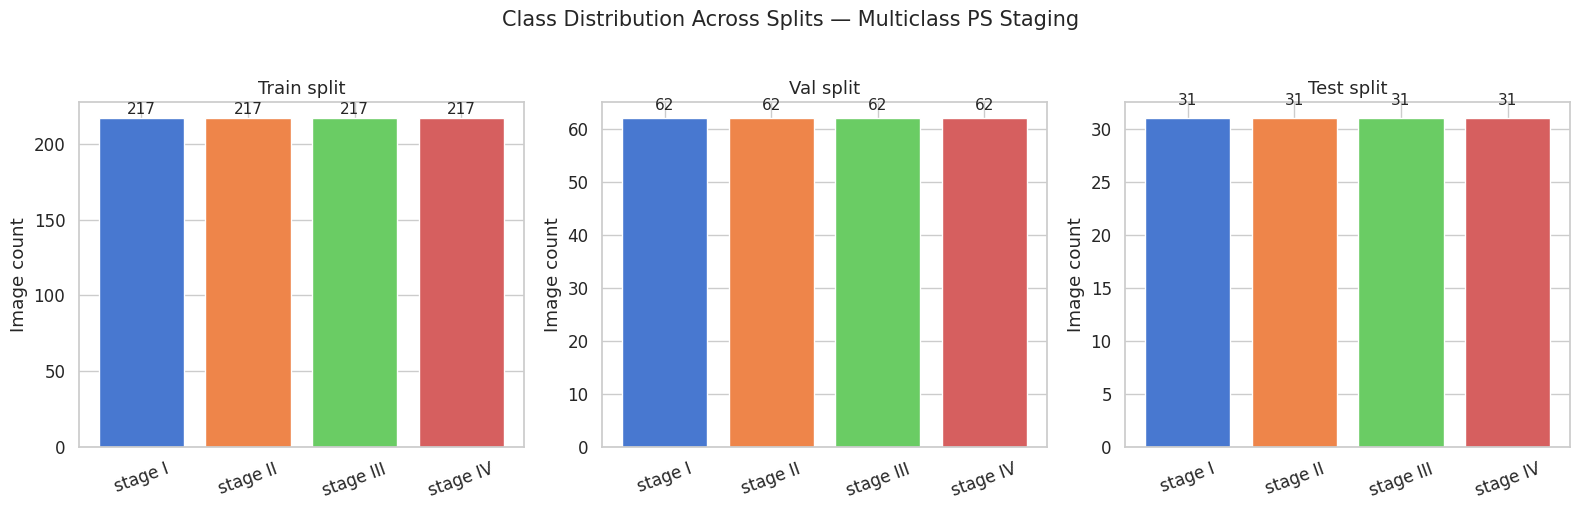

train  imbalance ratio (majority/minority): 1.00
val    imbalance ratio (majority/minority): 1.00
test   imbalance ratio (majority/minority): 1.00


In [4]:
splits  = list(split_counts.keys())
classes = list(next(iter(split_counts.values())).keys())

df_counts = pd.DataFrame(split_counts).T
df_counts["total"] = df_counts.sum(axis=1)
print("Image counts per split and class:")
display(df_counts)

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)
for ax, split in zip(axes, splits):
    vals = [split_counts[split].get(c, 0) for c in classes]
    bars = ax.bar(classes, vals, color=sns.color_palette("muted", len(classes)))
    ax.set_title(f"{split.capitalize()} split", fontsize=13)
    ax.set_ylabel("Image count")
    ax.tick_params(axis="x", rotation=20)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 1, str(v), ha="center", va="bottom", fontsize=11)

plt.suptitle("Class Distribution Across Splits — Multiclass PS Staging", fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig("/kaggle/working/class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

for split in splits:
    vals  = list(split_counts[split].values())
    ratio = max(vals) / min(vals) if min(vals) > 0 else float("inf")
    flag  = " ⚠️ consider augmentation" if ratio > 2.0 else ""
    print(f"{split:6s} imbalance ratio (majority/minority): {ratio:.2f}{flag}")

## 4. Training


In [5]:
model = YOLO(YOLO_BACKBONE)

results = model.train(
    data     = yolo_dataset_dir,
    epochs   = 100,
    imgsz    = 224,
    patience = 10,
    verbose  = True,
    project  = "/kaggle/working/runs",
    name     = RUN_NAME,
)

BEST_WEIGHTS = f"/kaggle/working/runs/{RUN_NAME}/weights/best.pt"
print(f"\nBest weights saved to: {BEST_WEIGHTS}")

Ultralytics 8.4.20 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/psdcb_yolo, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8x-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=multiclass_ps, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=10, per

## 5. Training Curve Analysis

Check for overfitting: train and val loss should converge. For a 4-class problem on a limited dataset, a moderate gap between train and val loss is expected - what matters is wether val accuracy plateaus at a clinically acceptable level.

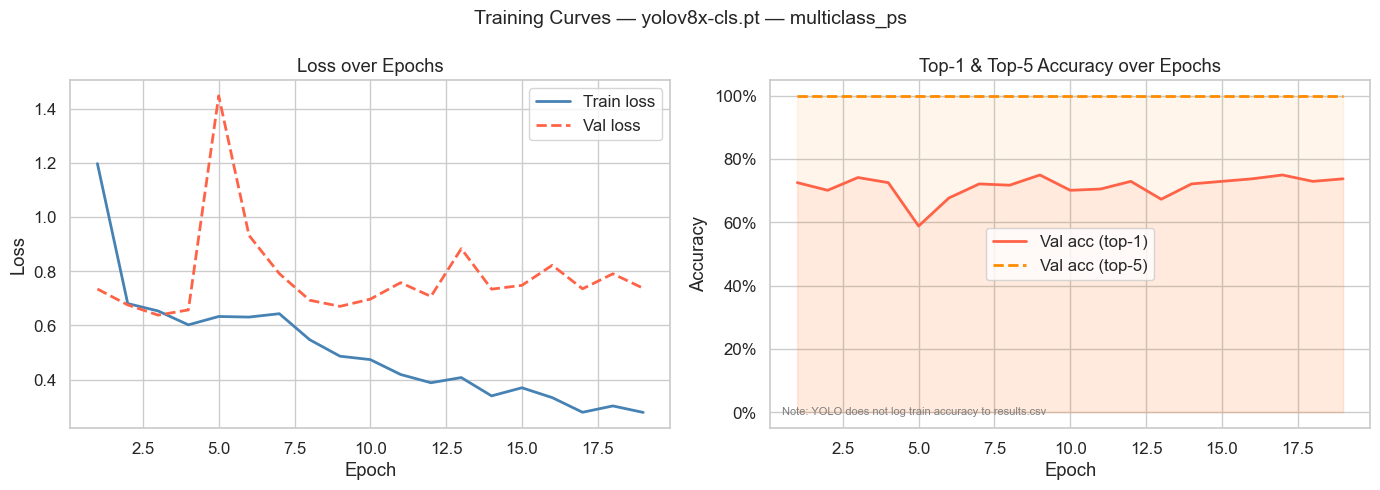

Best val top-1 accuracy at epoch 9 (0.7500)
Best val top-5 accuracy at epoch 1 (1.0000)


In [6]:
results_csv = Path(f"/kaggle/working/runs/{RUN_NAME}/results.csv")

if results_csv.exists():
    df = pd.read_csv(results_csv)
    df.columns = df.columns.str.strip()

    TRAIN_ACC_COL  = None  # YOLO never writes train accuracy
    VAL_ACC_COL    = "metrics/accuracy_top1"
    VAL_ACC5_COL   = "metrics/accuracy_top5"
    TRAIN_LOSS_COL = "train/loss"
    VAL_LOSS_COL   = "val/loss"

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Loss
    ax = axes[0]
    ax.plot(df["epoch"], df[TRAIN_LOSS_COL], label="Train loss", linewidth=2, color="steelblue")
    ax.plot(df["epoch"], df[VAL_LOSS_COL], label="Val loss", linewidth=2, color="tomato", linestyle="--")
    ax.set_title("Loss over Epochs")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()

    # Accuracy
    ax = axes[1]
    ax.plot(df["epoch"], df[VAL_ACC_COL],  label="Val acc (top-1)", linewidth=2, color="tomato")
    ax.plot(df["epoch"], df[VAL_ACC5_COL], label="Val acc (top-5)", linewidth=2, color="darkorange", linestyle="--")
    ax.fill_between(df["epoch"], df[VAL_ACC_COL],  alpha=0.08, color="tomato")
    ax.fill_between(df["epoch"], df[VAL_ACC5_COL], alpha=0.08, color="darkorange")
    ax.annotate("Note: YOLO does not log train accuracy to results.csv",
        xy=(0.02, 0.04), xycoords="axes fraction",
        fontsize=8, color="grey", style="italic"
    )
    ax.set_title("Top-1 & Top-5 Accuracy over Epochs")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
    ax.legend()

    plt.suptitle(f"Training Curves — {YOLO_BACKBONE} — {RUN_NAME}", fontsize=14)
    plt.tight_layout()
    plt.savefig("/kaggle/working/training_curves.png", dpi=150, bbox_inches="tight")
    plt.show()

    best_top1_idx = df[VAL_ACC_COL].idxmax()
    best_top5_idx = df[VAL_ACC5_COL].idxmax()
    print(f"Best val top-1 accuracy at epoch {int(df.loc[best_top1_idx, 'epoch'])} ({df.loc[best_top1_idx, VAL_ACC_COL]:.4f})")
    print(f"Best val top-5 accuracy at epoch {int(df.loc[best_top5_idx, 'epoch'])} ({df.loc[best_top5_idx, VAL_ACC5_COL]:.4f})")
else:
    print("results.csv not found — training may not have run yet.")

## 6. Evaluation - Confusion Matrix (Raw + Normalised)

Two views side by side:
* **Raw counts** - absolute numbers of correct/incorrect predictions.
* **Raw-normalised (recall per class)** - what fraction of each true class was correctly identified, independent of class size.

For staging, adjacent-class confusion (e.g. Stage II predicted as Stage III) is clinically more forgivable than skipping two stages (Stage I predicted as Stage IV).

Ultralytics 8.4.20 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8x-cls summary (fused): 54 layers, 56,128,324 parameters, 0 gradients, 153.8 GFLOPs
WARNING ⚠️ Dataset 'split=train' not found at /kaggle/working/psdcb_yolo/test/train
Found 123 images in subdirectories. Attempting to split...
Splitting /kaggle/working/psdcb_yolo/test (4 classes, 124 images) into 80% train, 20% val...
Split complete in /kaggle/working/psdcb_yolo/test_split ✅
WARNING ⚠️ Dataset 'split=test' not found, using 'split=val' instead.
train: /kaggle/working/psdcb_yolo/test_split/train... found 96 images in 4 classes ✅ 
val: /kaggle/working/psdcb_yolo/test_split/val... found 28 images in 4 classes ✅ 
test: /kaggle/working/psdcb_yolo/test_split/val... found 28 images in 4 classes ✅ 
test: Fast image access ✅ (ping: 0.0±0.0 ms, read: 263.3±104.9 MB/s, size: 9.9 KB)
test: Scanning /kaggle/working/psdcb_yolo/test_split/val... 28 images, 0 corrupt: 100% ━━━━━━━━━━━━ 28/28 2.9Kit/s 0.0s
test: New c

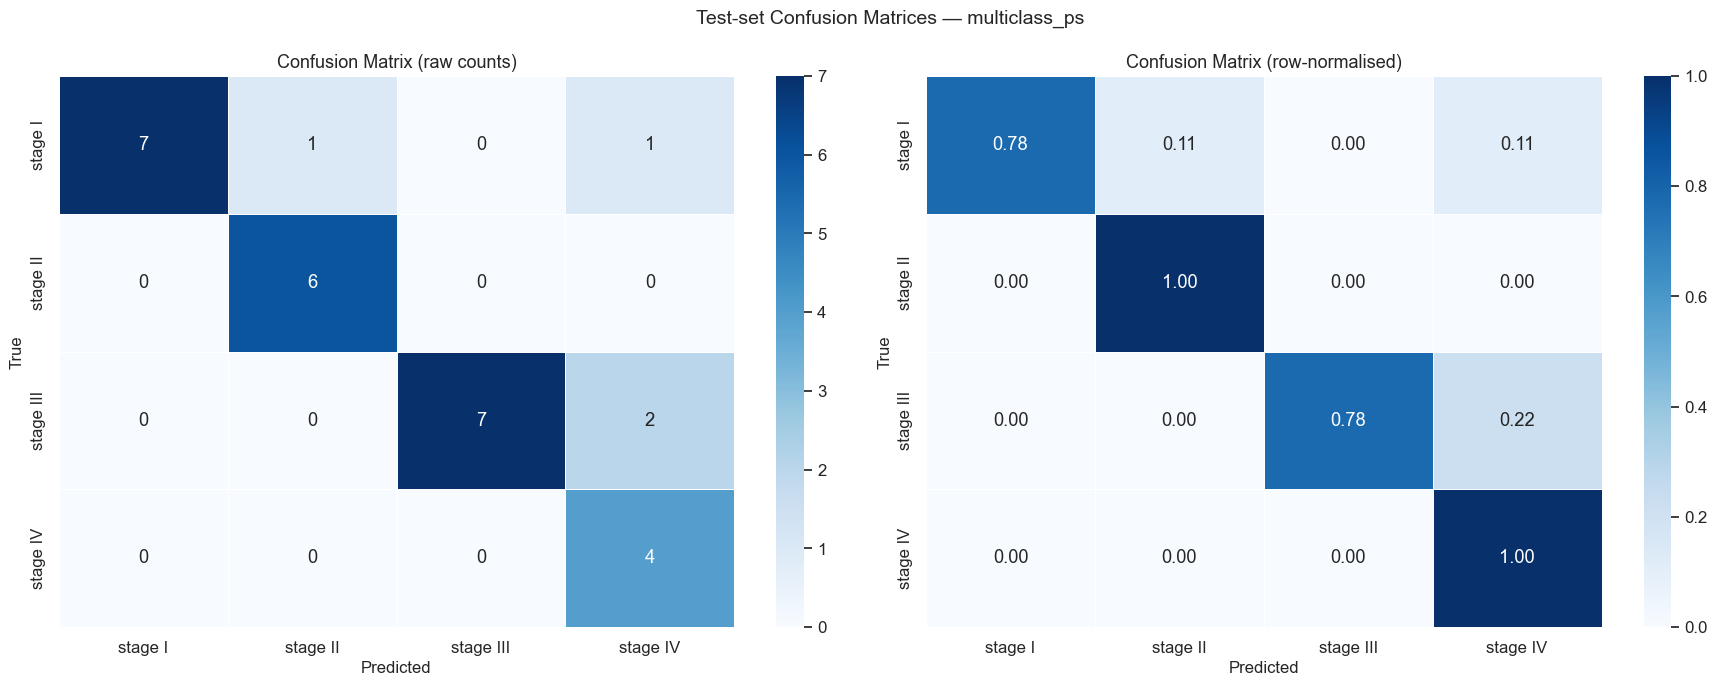


Raw confusion matrix:
           stage I  stage II  stage III  stage IV
stage I          7         1          0         1
stage II         0         6          0         0
stage III        0         0          7         2
stage IV         0         0          0         4


In [7]:
model = YOLO(BEST_WEIGHTS)

test_dir = os.path.join(yolo_dataset_dir, "test")
metrics  = model.val(data=test_dir, split="test")

# YOLO appends a background class → matrix is (n_classes+1) × (n_classes+1)
n_real = len(model.names)
cm_full = metrics.confusion_matrix.matrix.astype(int)
cm_raw  = cm_full[:n_real, :n_real]
class_names = [model.names[i] for i in range(n_real)]

print(f"Full YOLO matrix shape : {cm_full.shape}")
print(f"Trimmed matrix shape : {cm_raw.shape}")
print(f"Classes : {class_names}")

cm_norm = cm_raw.astype(float) / cm_raw.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, cm, title, fmt in zip(
    axes,
    [cm_raw, cm_norm],
    ["Confusion Matrix (raw counts)", "Confusion Matrix (row-normalised)"],
    ["d", ".2f"],
):
    sns.heatmap(
        cm, annot=True, fmt=fmt, cmap="Blues",
        xticklabels=class_names, yticklabels=class_names,
        linewidths=0.5, ax=ax,
    )
    ax.set_xlabel("Predicted", fontsize=12)
    ax.set_ylabel("True", fontsize=12)
    ax.set_title(title, fontsize=13)

plt.suptitle(f"Test-set Confusion Matrices — {RUN_NAME}", fontsize=14)
plt.tight_layout()
plt.savefig("/kaggle/working/confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nRaw confusion matrix:")
print(pd.DataFrame(cm_raw, index=class_names, columns=class_names))

## 7. Evaluation - Full Classification Report

Per-class precision, recall, and F1. Both macro and weighted averages shown.

> **Macro vs Weighted** : Macro averages treat all classes equally regardless of sample count - it exposes poor performance on minority classes (e.g. Stage IV) that weighted averaging would mask

In [8]:
# Reconstruct y_true / y_pred from the confusion matrix
y_true, y_pred = [], []
for true_idx in range(cm_raw.shape[0]):
    for pred_idx in range(cm_raw.shape[1]):
        count = int(cm_raw[true_idx, pred_idx])
        y_true.extend([true_idx] * count)
        y_pred.extend([pred_idx] * count)

print("=" * 55)
print("CLASSIFICATION REPORT — TEST SET")
print("=" * 55)
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

summary = {
    "Accuracy": accuracy_score(y_true, y_pred),
    "Macro Precision": precision_score(y_true, y_pred, average="macro"),
    "Macro Recall": recall_score(y_true, y_pred, average="macro"),
    "Macro F1": f1_score(y_true, y_pred, average="macro"),
    "Weighted Precision": precision_score(y_true, y_pred, average="weighted"),
    "Weighted Recall": recall_score(y_true, y_pred, average="weighted"),
    "Weighted F1": f1_score(y_true, y_pred, average="weighted"),
}

df_summary = pd.DataFrame(summary.items(), columns=["Metric", "Value"])
df_summary["Value"] = df_summary["Value"].map("{:.4f}".format)
print()
display(df_summary.set_index("Metric"))
df_summary.to_csv("/kaggle/working/metrics_summary.csv", index=False)
print("\nMetrics saved to metrics_summary.csv")

CLASSIFICATION REPORT — TEST SET
              precision    recall  f1-score   support

     stage I     1.0000    0.7778    0.8750         9
    stage II     0.8571    1.0000    0.9231         6
   stage III     1.0000    0.7778    0.8750         9
    stage IV     0.5714    1.0000    0.7273         4

    accuracy                         0.8571        28
   macro avg     0.8571    0.8889    0.8501        28
weighted avg     0.9082    0.8571    0.8642        28




,Value
Metric,
Accuracy,0.8571
Macro Precision,0.8571
Macro Recall,0.8889
Macro F1,0.8501
Weighted Precision,0.9082
Weighted Recall,0.8571
Weighted F1,0.8642



Metrics saved to metrics_summary.csv


## 8. Evaluation - Per-Class ROC Curves & AUC (One vs Rest)

For multiclass problems, ROC/AUC is computed using a **One vs Rest (OvR)** strategy: each class is treated as the positive class while all others are treated as negative. This gives one curve per stage plus a macro-average AUC.

AUC = 1.0 is perfect. AUC = 0.5 is random. A macro AUC above 0.85 on a 4-class medical dataset with limited data is a strong result.

Collected probabilities for 124 test images.
  stage I: 31 images
  stage II: 31 images
  stage III: 31 images
  stage IV: 31 images


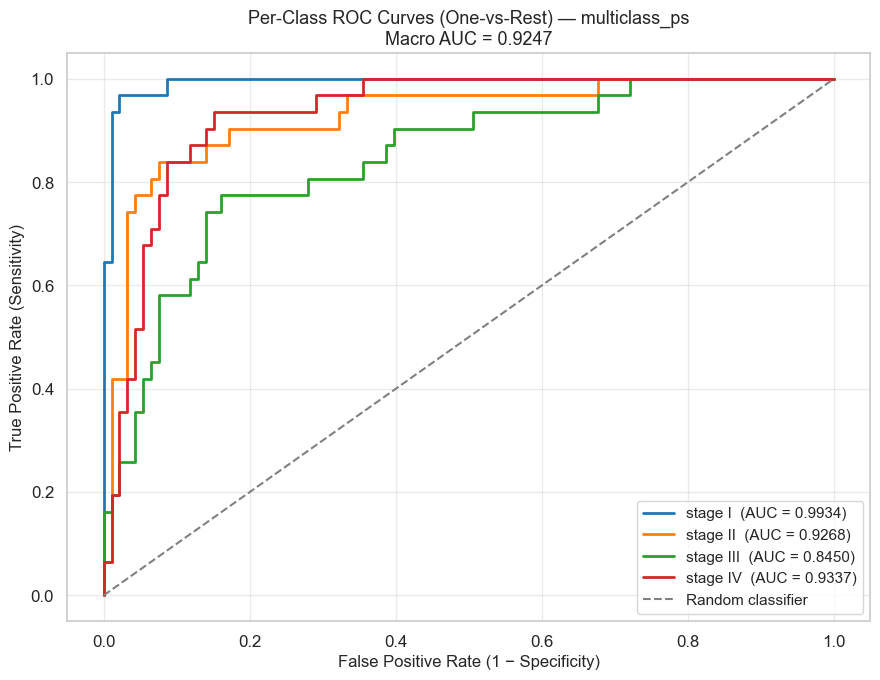


Macro AUC-ROC (OvR): 0.9247
stage I: 0.9934
stage II: 0.9268
stage III: 0.8450
stage IV: 0.9337


In [9]:
# Collect per-image softmax probabilities from the test set
test_images, gt_labels, all_probs = [], [], []

for class_idx, class_name in model.names.items():
    class_dir = Path(test_dir) / class_name
    if not class_dir.exists():
        continue
    for img_path in class_dir.glob("*"):
        if img_path.suffix.lower() not in {".jpg", ".jpeg", ".png", ".webp"}:
            continue
        result = model(str(img_path), verbose=False)[0]
        probs  = result.probs.data.cpu().numpy()
        all_probs.append(probs)
        gt_labels.append(class_idx)
        test_images.append(str(img_path))

all_probs = np.array(all_probs)   # shape: (n_samples, n_classes)
gt_labels = np.array(gt_labels)

print(f"Collected probabilities for {len(gt_labels)} test images.")
for i, name in enumerate(class_names):
    print(f"  {name}: {(gt_labels == i).sum()} images")

# Binarize labels for OvR ROC
n_classes = len(class_names)
y_bin = label_binarize(gt_labels, classes=list(range(n_classes)))

# Per-class ROC
colors = sns.color_palette("tab10", n_classes)
fig, ax = plt.subplots(figsize=(9, 7))

auc_scores = {}
for i, (name, color) in enumerate(zip(class_names, colors)):
    if y_bin[:, i].sum() == 0:
        print(f"⚠️ Class '{name}' has no positive samples in test set — skipping ROC.")
        continue
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    auc_val = roc_auc_score(y_bin[:, i], all_probs[:, i])
    auc_scores[name] = auc_val
    ax.plot(fpr, tpr, lw=2, color=color, label=f"{name}  (AUC = {auc_val:.4f})")

# Macro AUC
macro_auc = roc_auc_score(y_bin, all_probs, average="macro", multi_class="ovr")
ax.plot([0, 1], [0, 1], linestyle="--", color="grey", lw=1.5, label="Random classifier")
ax.set_xlabel("False Positive Rate (1 − Specificity)", fontsize=12)
ax.set_ylabel("True Positive Rate (Sensitivity)",      fontsize=12)
ax.set_title(
    f"Per-Class ROC Curves (One-vs-Rest) — {RUN_NAME}\nMacro AUC = {macro_auc:.4f}",
    fontsize=13
)
ax.legend(fontsize=11, loc="lower right")
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig("/kaggle/working/roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nMacro AUC-ROC (OvR): {macro_auc:.4f}")
for name, auc_val in auc_scores.items():
    print(f"{name}: {auc_val:.4f}")

## 9. Evaluation - Per-Class Probability Distributions

For each true class, this plot shows how the model distributed its confidence across all four predicted classes. A well-calibrated model concentrates probability mass on the correct class (tall bar on the diagonal). Spread across adjacent classes reveals systematic confusion patterns.

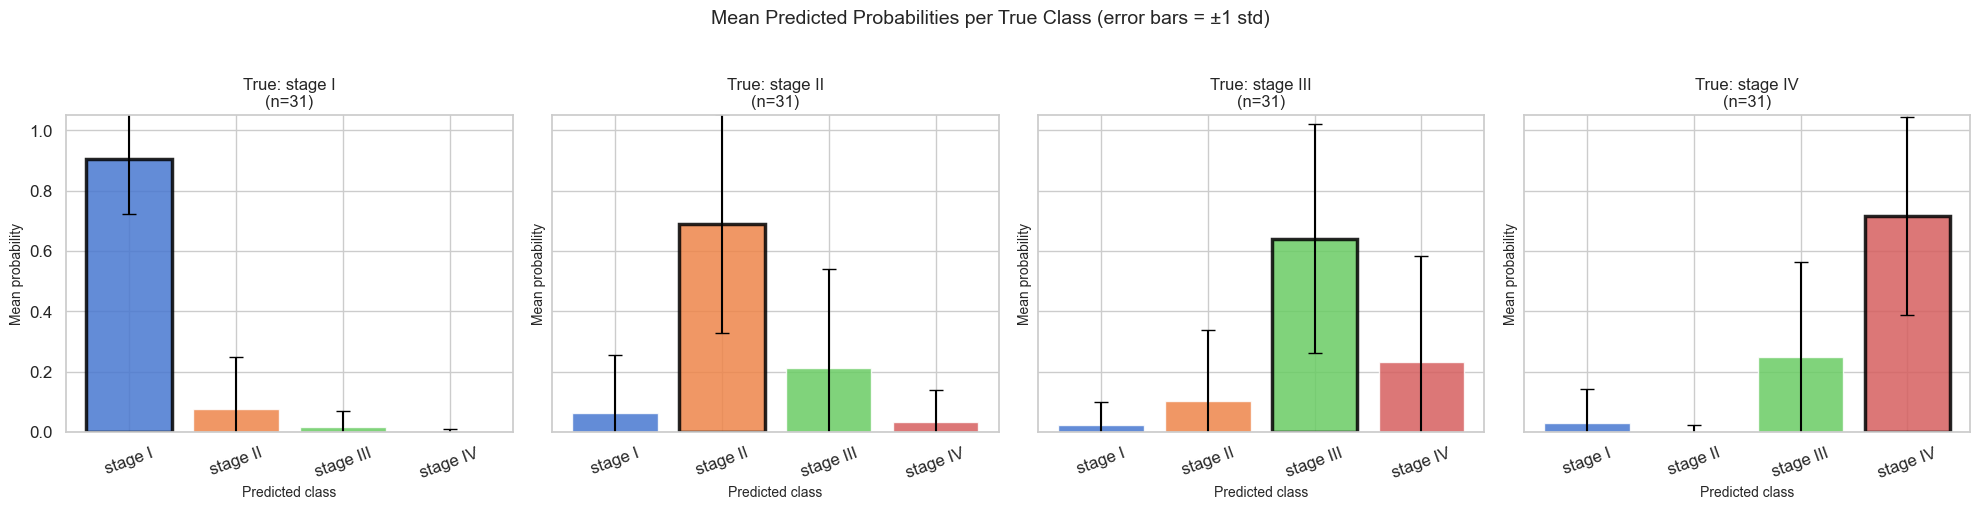

In [10]:
fig, axes = plt.subplots(1, n_classes, figsize=(5 * n_classes, 5), sharey=True)

colors = sns.color_palette("muted", n_classes)

for true_idx, (ax, true_name) in enumerate(zip(axes, class_names)):
    mask = gt_labels == true_idx
    class_probs = all_probs[mask] 
    mean_probs = class_probs.mean(axis=0)
    std_probs = class_probs.std(axis=0)

    bars = ax.bar(
        class_names, mean_probs,
        color=[colors[i] for i in range(n_classes)],
        alpha=0.85,
    )
    ax.errorbar(
        class_names, mean_probs, yerr=std_probs,
        fmt="none", color="black", capsize=5, linewidth=1.5
    )
    # Highlight the correct class bar
    bars[true_idx].set_edgecolor("black")
    bars[true_idx].set_linewidth(2.5)

    ax.set_title(f"True: {true_name}\n(n={mask.sum()})", fontsize=12)
    ax.set_xlabel("Predicted class", fontsize=10)
    ax.set_ylabel("Mean probability", fontsize=10)
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis="x", rotation=20)

plt.suptitle(
    "Mean Predicted Probabilities per True Class (error bars = ±1 std)",
    fontsize=14, y=1.02
)
plt.tight_layout()
plt.savefig("/kaggle/working/probability_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Model Export & Run Summary


In [12]:
print("=" * 55)
print("TRAINING & EVALUATION SUMMARY")
print("=" * 55)
print(f"Run name : {RUN_NAME}")
print(f"Backbone : {YOLO_BACKBONE}")
print(f"Best weights : {BEST_WEIGHTS}")
print(f"Classes : {class_names}")
print(f"Test images : {len(gt_labels)}")
print()
print(f"Accuracy : {accuracy_score(y_true, y_pred):.4f}")
print(f"Macro Precision : {precision_score(y_true, y_pred, average='macro'):.4f}")
print(f"Macro Recall : {recall_score(y_true, y_pred, average='macro'):.4f}")
print(f"Macro F1 : {f1_score(y_true, y_pred, average='macro'):.4f}")
print(f"Weighted F1 : {f1_score(y_true, y_pred, average='weighted'):.4f}")
print(f"Macro AUC-ROC (OvR) : {macro_auc:.4f}")
print()
print("  Per-class AUC-ROC:")
for name, auc_val in auc_scores.items():
    print(f"{name} : {auc_val:.4f}")
print()
print("Saved artefacts:")
for fname in [
    "class_distribution.png",
    "training_curves.png",
    "confusion_matrices.png",
    "roc_curves.png",
    "probability_distributions.png",
    "sample_predictions.png",
    "metrics_summary.csv",
]:
    path = Path("/kaggle/working") / fname
    status = "✅" if path.exists() else "❌ missing"
    print(f"{status} {fname}")

TRAINING & EVALUATION SUMMARY
Run name : multiclass_ps
Backbone : yolov8x-cls.pt
Best weights : /kaggle/working/runs/multiclass_ps/weights/best.pt
Classes : ['stage I', 'stage II', 'stage III', 'stage IV']
Test images : 124

Accuracy : 0.8571
Macro Precision : 0.8571
Macro Recall : 0.8889
Macro F1 : 0.8501
Weighted F1 : 0.8642
Macro AUC-ROC (OvR) : 0.9247

  Per-class AUC-ROC:
stage I : 0.9934
stage II : 0.9268
stage III : 0.8450
stage IV : 0.9337

Saved artefacts:
✅ class_distribution.png
✅ training_curves.png
✅ confusion_matrices.png
✅ roc_curves.png
✅ probability_distributions.png
✅ sample_predictions.png
✅ metrics_summary.csv
